In [6]:
import json
import pandas as pd
import os
def gen_dataframe(s):
    l = []
    for fol in os.listdir(s):
        if not os.path.isdir(os.path.join(s, fol)):
                continue
        for folder in os.listdir(os.path.join(s, fol)):
            folder = os.path.join(s, fol, folder)
            if os.path.isdir(folder):
                with open(os.path.join(folder, "result.json"), "r") as f:
                    try:    
                        res = json.load(f)
                    except:
                        continue

                res.pop("config")
                with open(os.path.join(folder, "params.json"), "r") as f:
                    params = json.load(f)
                
                for k, v in params.items():
                    res[f"config/{k}"] = v

                l.append(res)
    df = pd.DataFrame(l)
    # df.to_pickle(os.path.join(s, "analysis_results.pkl"))
    return df
    

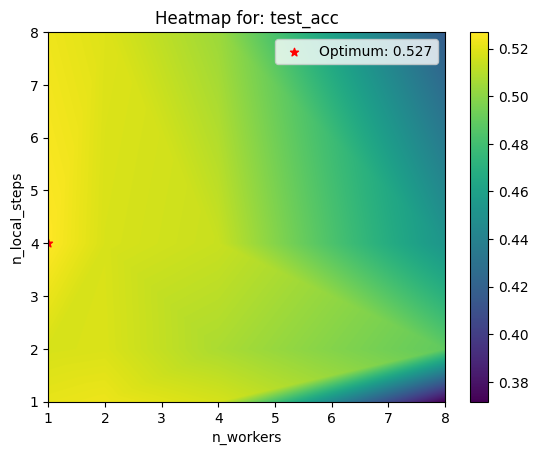

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import LinearNDInterpolator

def hyper_params_heatmap(results, param_1_name, param_2_name, log_scale_1=True, 
                         log_scale_2=True, metric="val_acc", mode="max", log_metric=False):
    x = results[f"config/{param_1_name}"]
    y = results[f"config/{param_2_name}"]

    if log_scale_1:
        x = np.log10(x)
        param_1_name = "Exponent of: " + param_1_name
    if log_scale_2:
        y = np.log10(y)
        param_2_name = "Exponent of: " + param_2_name

    val = results[metric] 

    if log_metric:
        val = np.log(val)

    inter = LinearNDInterpolator((x, y), val)

    x_int = np.linspace(x.min(), x.max(), 1000)
    y_int = np.linspace(y.min(), y.max(), 1000)
    mesh = np.meshgrid(x_int, y_int)
    inter_val = inter(mesh)

    plt.imshow(inter_val, extent=[x_int[0], x_int[-1], y_int[0], y_int[-1]], origin="lower", aspect="auto")
    plt.colorbar()

    opt_ind = np.argmax(val) if mode == "max" else np.argmin(val)
    # plt.scatter(x, y)
    plt.scatter(x[opt_ind], y[opt_ind], c="r", marker="*", label=f"Optimum: {val[opt_ind]}")

    plt.xlabel(param_1_name)
    plt.ylabel(param_2_name)
    
    if log_metric:
        plt.title(f"Heatmap for: log({metric})")
    else:
        plt.title(f"Heatmap for: {metric}")
    plt.legend()

folder = r"Results2\local_sgd"#r"Results2\mini_batch_adamw\tune_distributed_learning_2025-01-19_22-36-14"
df = gen_dataframe(folder)

# hyper_params_heatmap(df, "local_opt.lr", "local_opt.weight_decay", True, True)#, "val_loss", "min", True)
# hyper_params_heatmap(df, "local_batch_size", "local_opt.lr", False, True, "val_acc", "max", False)
hyper_params_heatmap(df, "n_workers", "n_local_steps", False, False, "test_acc")
# plt.savefig(os.path.join(folder, "heatmap_plot_loss.png"))

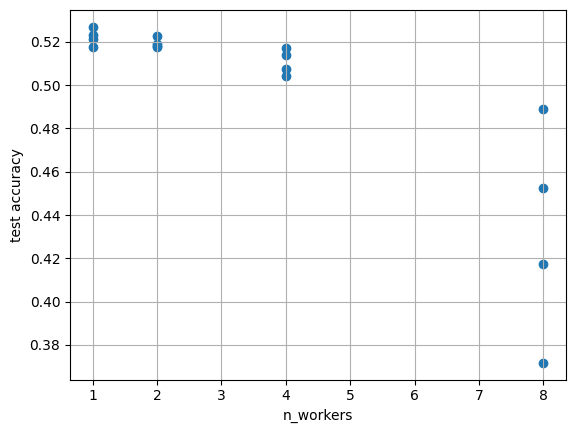

In [22]:
plt.scatter(df["config/n_workers"], df["test_acc"])
# plt.xscale("log")
# plt.xlabel("local learning rate")
plt.xlabel("n_workers")
plt.ylabel("test accuracy")
# opt_ind = np.argmax(df["val_acc"])
# plt.scatter(x, y)
# plt.scatter(df["config/local_opt.lr"][opt_ind], df["val_acc"][opt_ind], c="r", marker="*", label=f"Optimum: {df["val_acc"][opt_ind]}")
plt.grid()
plt.savefig(os.path.join(folder, "results.png"))

ConversionError: Failed to convert value(s) to axis units: array([None, None, None, None, None, None, None, None, None, None, None,
       None, None, None, None, None], dtype=object)

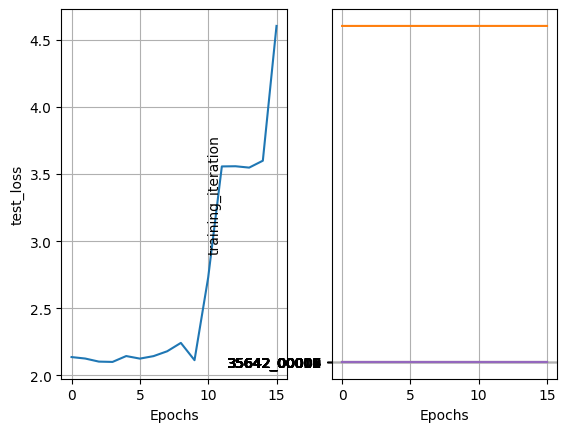

In [ ]:
df.sort_values("val_acc", ascending=False)

In [11]:
import statsmodels.api as sm


def control_for(df, name, metric, log=False):
    
    coeffs = sm.OLS(df[metric], sm.add_constant(df[])).fit().params

    return df[metric] + coeffs[f"config/{name}"] * (df[f"config/{name}"].mean() - df[f"config/{name}"])


plt.scatter(df["config/n_local_steps"], control_for(df, "n_workers", "val_loss"))

In [ ]:
import numpy as np
np.random.permutation(10)

In [ ]:
df.filter(["config/local_opt.lr", "config/local_opt.weight_decay", "val_loss"]).sort_values("val_loss")#.sort_values("val_acc", ascending=False)

In [ ]:
[2**i for i in range(1, 9)]